# Tutorial - Populations

The NV center is read out and initialized optically. Under green laser excitation the spin-conserving optical cycle pumps population, but the **inter-system crossing (ISC)** to the metastable singlet is **spin-selective** (faster from $m_s=\pm1$), which polarizes the spin into $m_s=0$ after a few microseconds. This notebook follows the level populations through a

$$\text{Laser (prepare, 10 us)} \to \text{Free (1 us)} \to \text{MW (5 us)} \to \text{Laser (readout, 6 us)}$$

sequence, with the laser/MW/free intervals shaded. We compare the **7-level** (no-HF) model with the **14-level** Doherty model (NV $\otimes\ ^{15}$N), and also show a variant where the MW segment is a single **$\pi$-pulse** instead of a 5 us drive.

Units: times in microseconds (us). `RECOMPUTE = True` recomputes; `False` loads the shipped cache.

In [1]:
RECOMPUTE = False
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from examples import protocol_runs as engine

## 7-level (no hyperfine), MW = 5 us

loaded cached -> /home/arturvdom/Research/PhD-Quantum-Control/examples/RawData/example_populations_no-HF/populations_no-HF.npy
saved populations_no-HF_dark_theme.png + populations_no-HF_light_theme.png (presentation figures/ + examples/Figures/)


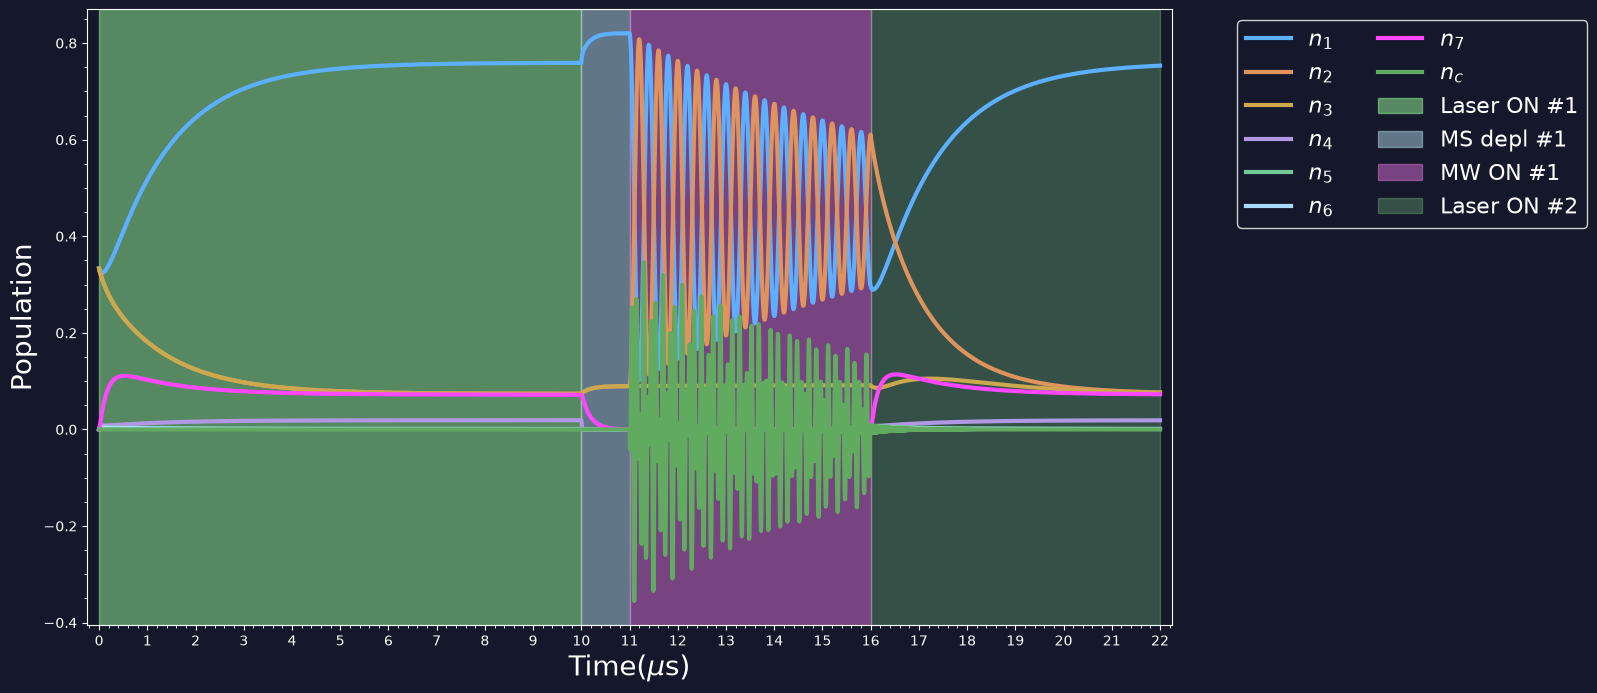

In [2]:
pop7 = engine.run_or_load(
    "populations_no-HF",
    lambda: engine.compute_populations(model_label="no-HF", mw_time=5.0),
    recompute=RECOMPUTE,
)
engine.plot_populations_result(pop7, save_as="populations_no-HF.png")

## 14-level (Doherty hyperfine), MW = 5 us

loaded cached -> /home/arturvdom/Research/PhD-Quantum-Control/examples/RawData/example_populations_Doherty/populations_Doherty.npy
saved populations_Doherty_dark_theme.png + populations_Doherty_light_theme.png (presentation figures/ + examples/Figures/)


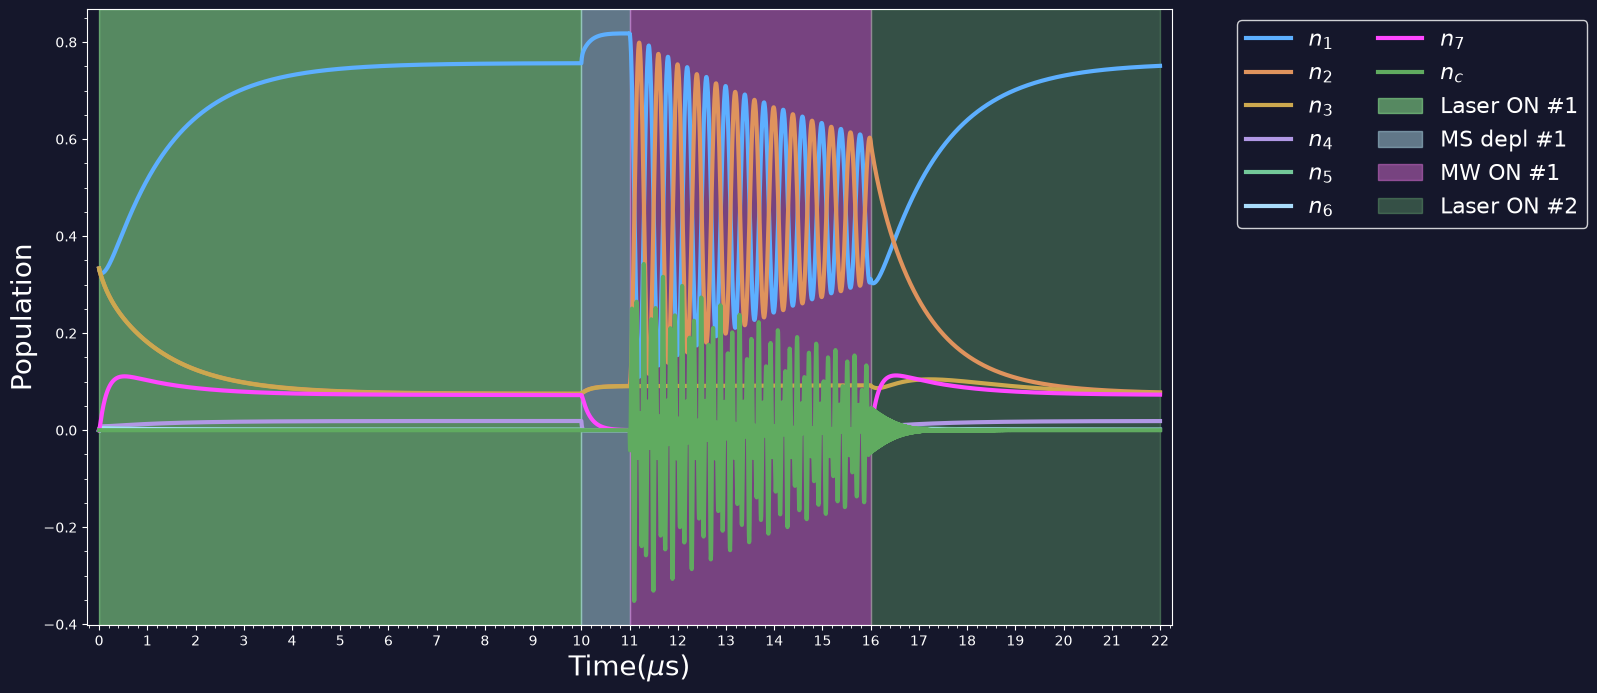

In [3]:
pop14 = engine.run_or_load(
    "populations_Doherty",
    lambda: engine.compute_populations(model_label="Doherty", mw_time=5.0),
    recompute=RECOMPUTE,
)
engine.plot_populations_result(pop14, save_as="populations_Doherty.png")

## 7-level vs 14-level comparison

The hyperfine structure barely changes the population dynamics on this timescale — the optical pumping is set by the electronic ISC rates, not the nuclear spin.

saved populations_comparison_dark_theme.png + populations_comparison_light_theme.png (presentation figures/ + examples/Figures/)


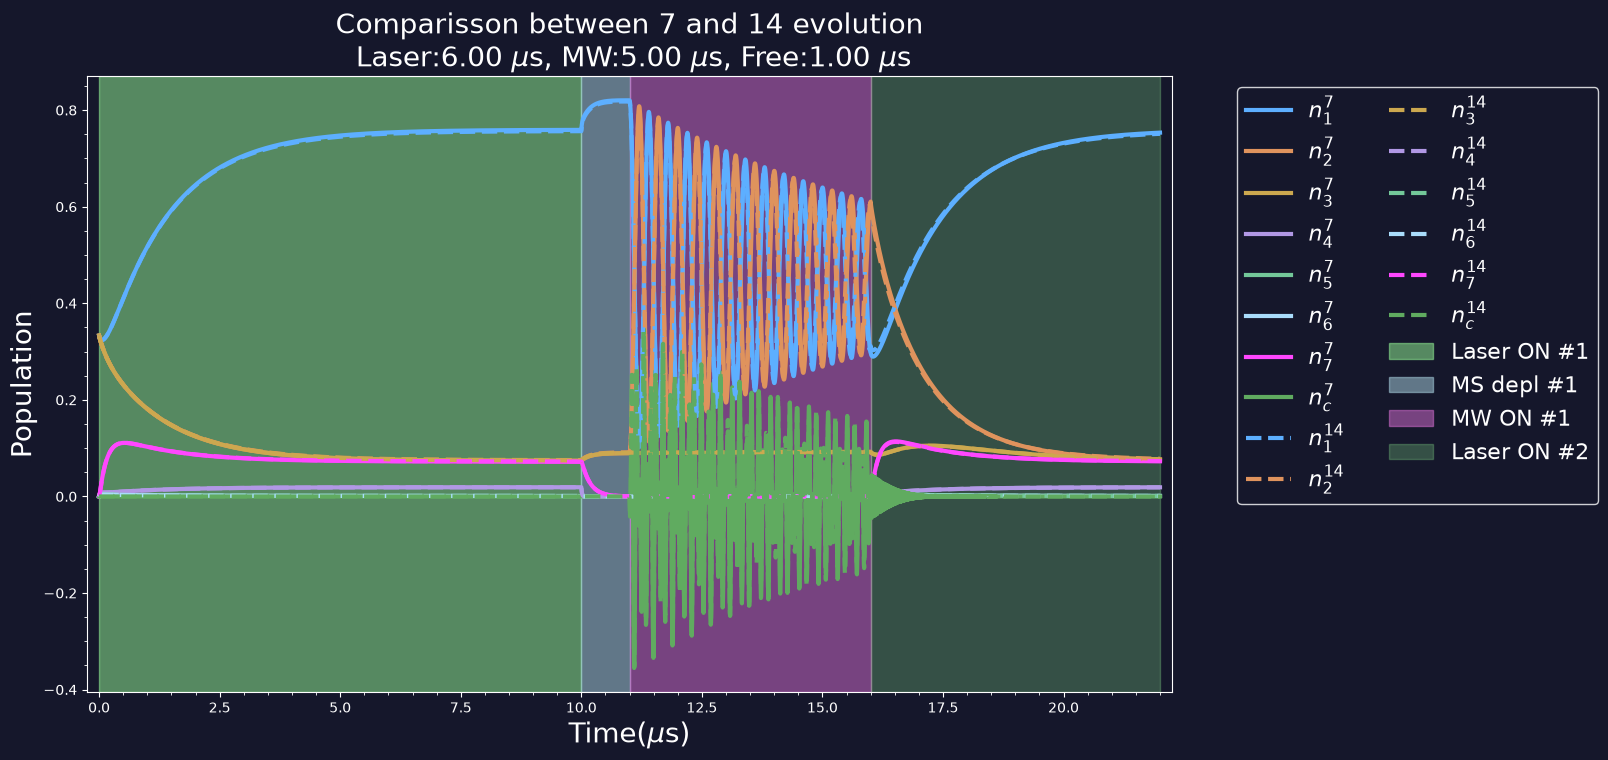

In [4]:
engine.plot_populations_comparison_result(pop7, pop14, name_a="7", name_b="14")

## MW as a single $\pi$-pulse (instead of 5 us)

Just for illustration: with `mw_time=None` the MW segment is a single $\pi$-pulse ($\pi/\Omega_r \approx 0.2$ us) — the MW interval is now a thin spike.

loaded cached -> /home/arturvdom/Research/PhD-Quantum-Control/examples/RawData/example_populations_pi_pulse/populations_pi_pulse.npy
saved populations_pi_pulse_dark_theme.png + populations_pi_pulse_light_theme.png (presentation figures/ + examples/Figures/)


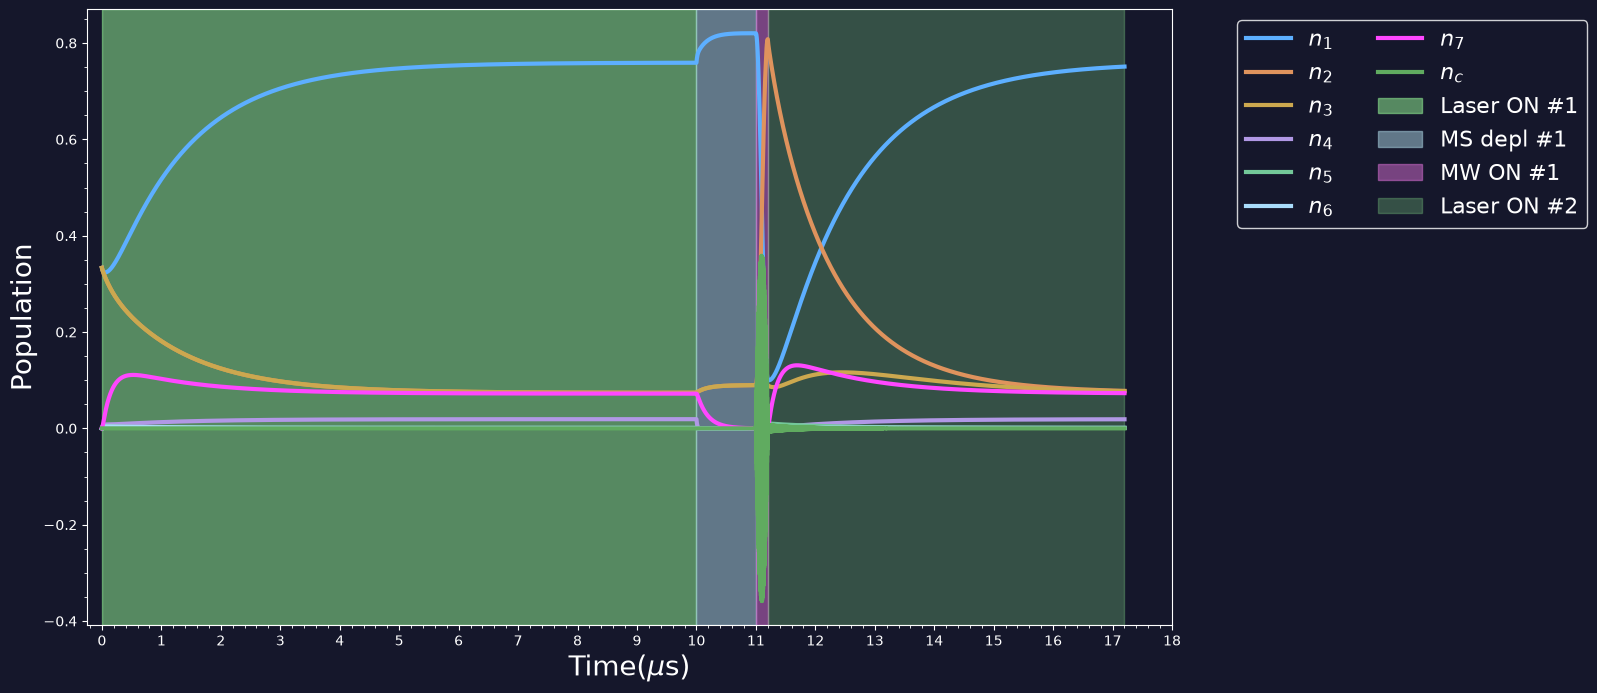

In [5]:
pop_pi = engine.run_or_load(
    "populations_pi_pulse",
    lambda: engine.compute_populations(model_label="no-HF", mw_time=None),
    recompute=RECOMPUTE,
)
engine.plot_populations_result(pop_pi, save_as="populations_pi_pulse.png")

## Populations vs transition-rate set (K_S)

The ISC / radiative rates are only known to within a model (`core.constants` ships several `K_S` sets). Here the **full level populations** ($n_1\ldots n_7, n_c$) over a Laser→Free→MW→Laser sequence are overlaid for every `K_S` set: the highlighted set is drawn in the per-state palette, the others greyed, so you can see how strongly the rate model shapes the dynamics (masters *Comparison of Transition Rates*). **Long calculation** (one full sequence per rate set); set `RECOMPUTE=True` to run.

loaded cached -> /home/arturvdom/Research/PhD-Quantum-Control/examples/RawData/example_populations_ks_no-HF/populations_ks_no-HF.npy
saved populations_ks_no-HF_dark_theme.png + populations_ks_no-HF_light_theme.png (presentation figures/ + examples/Figures/)


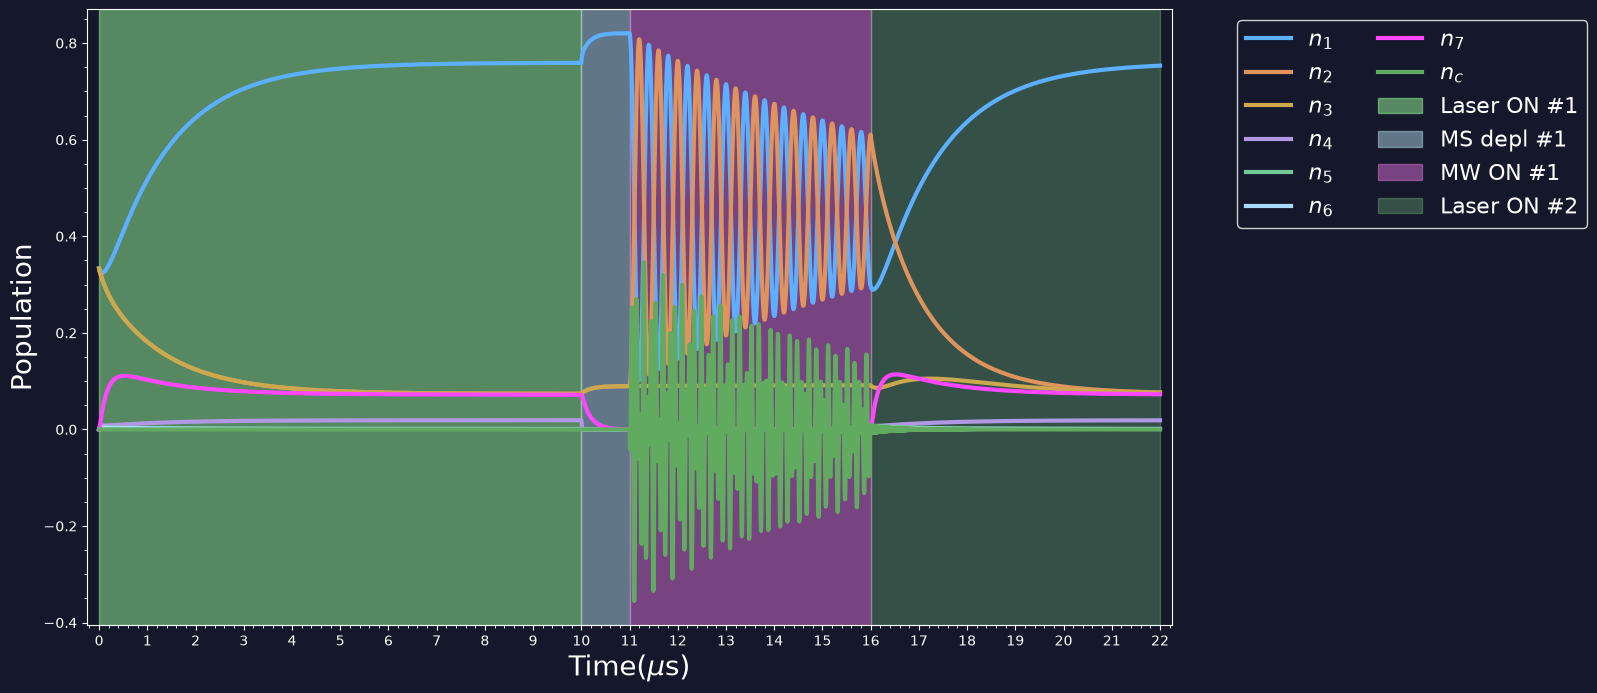

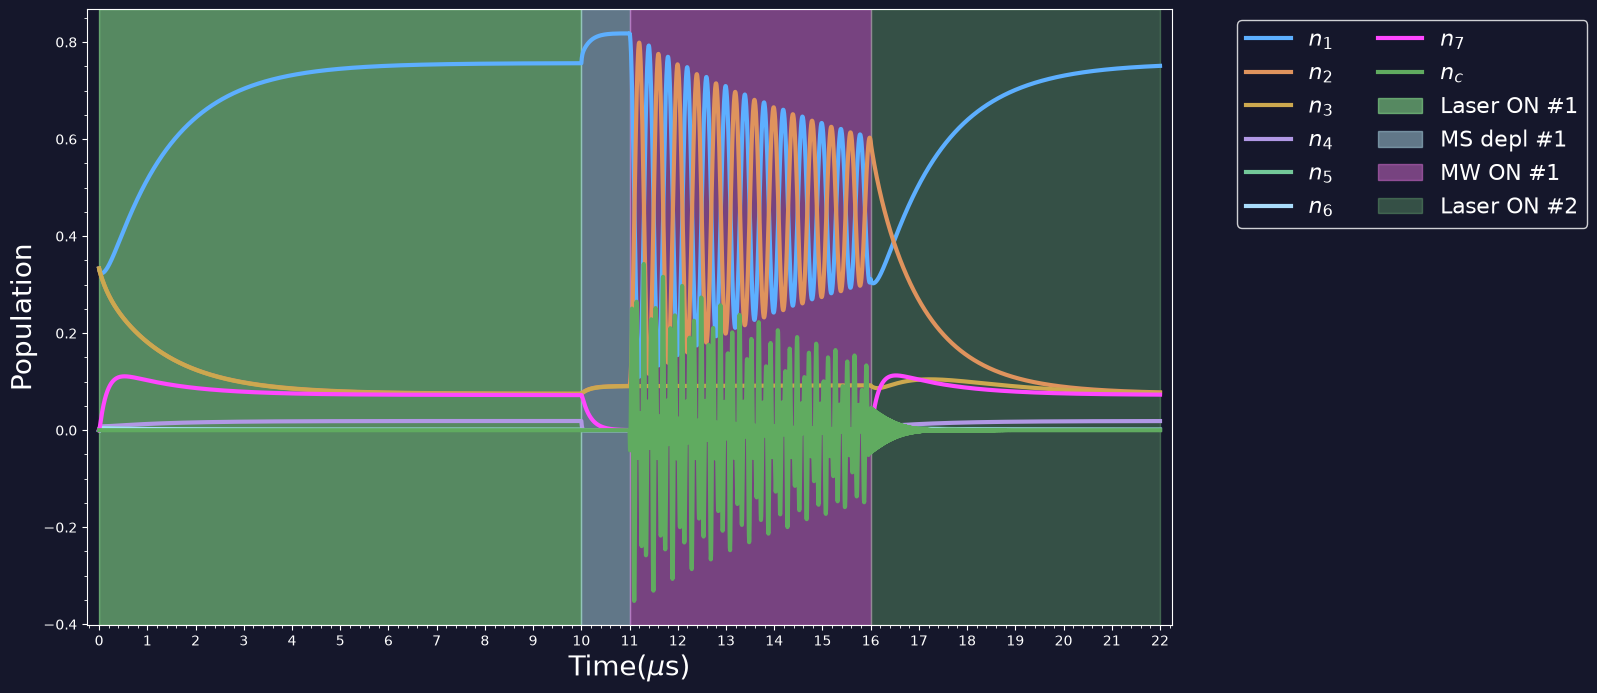

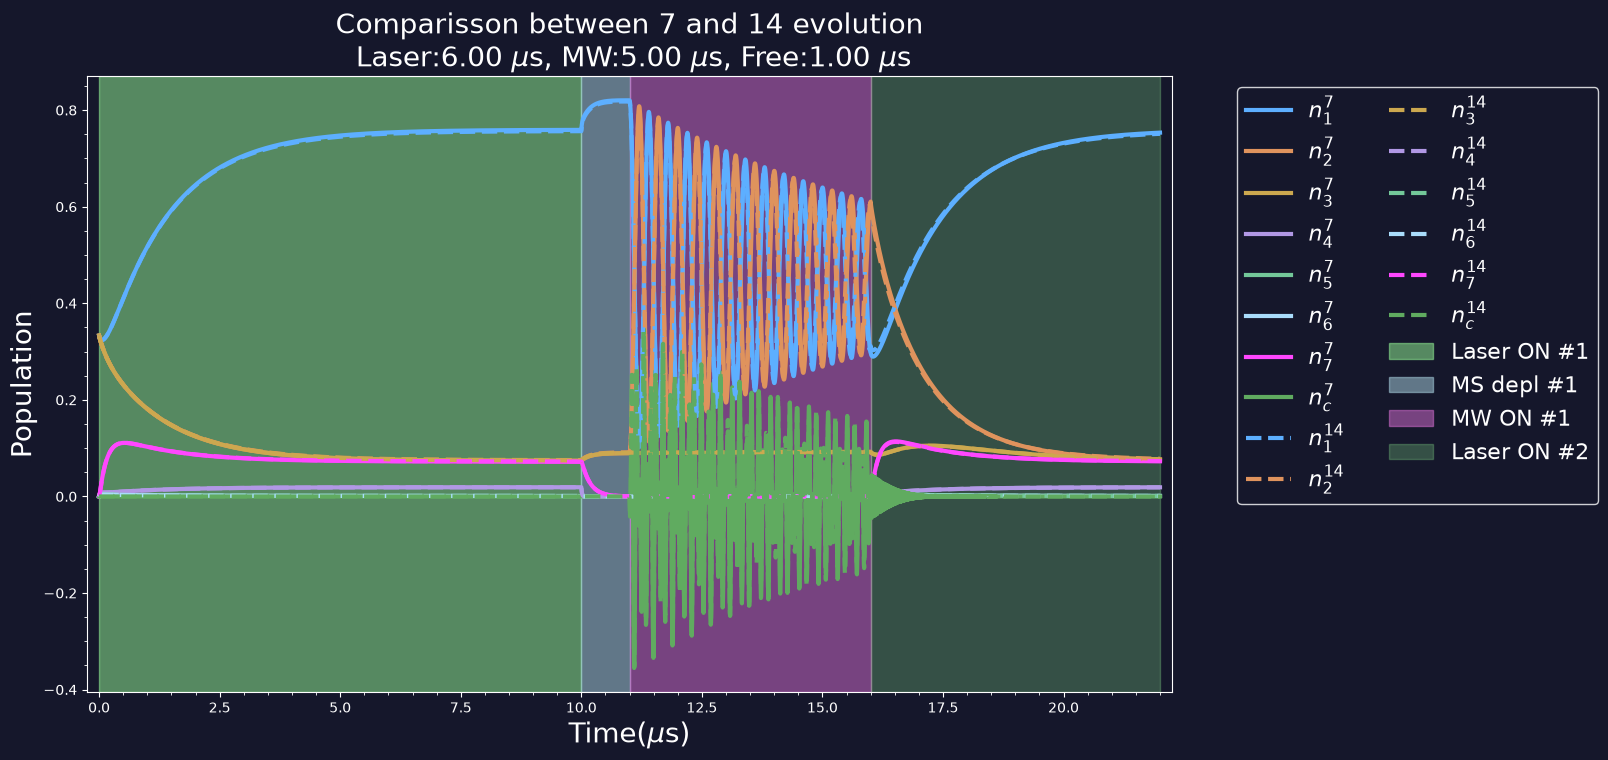

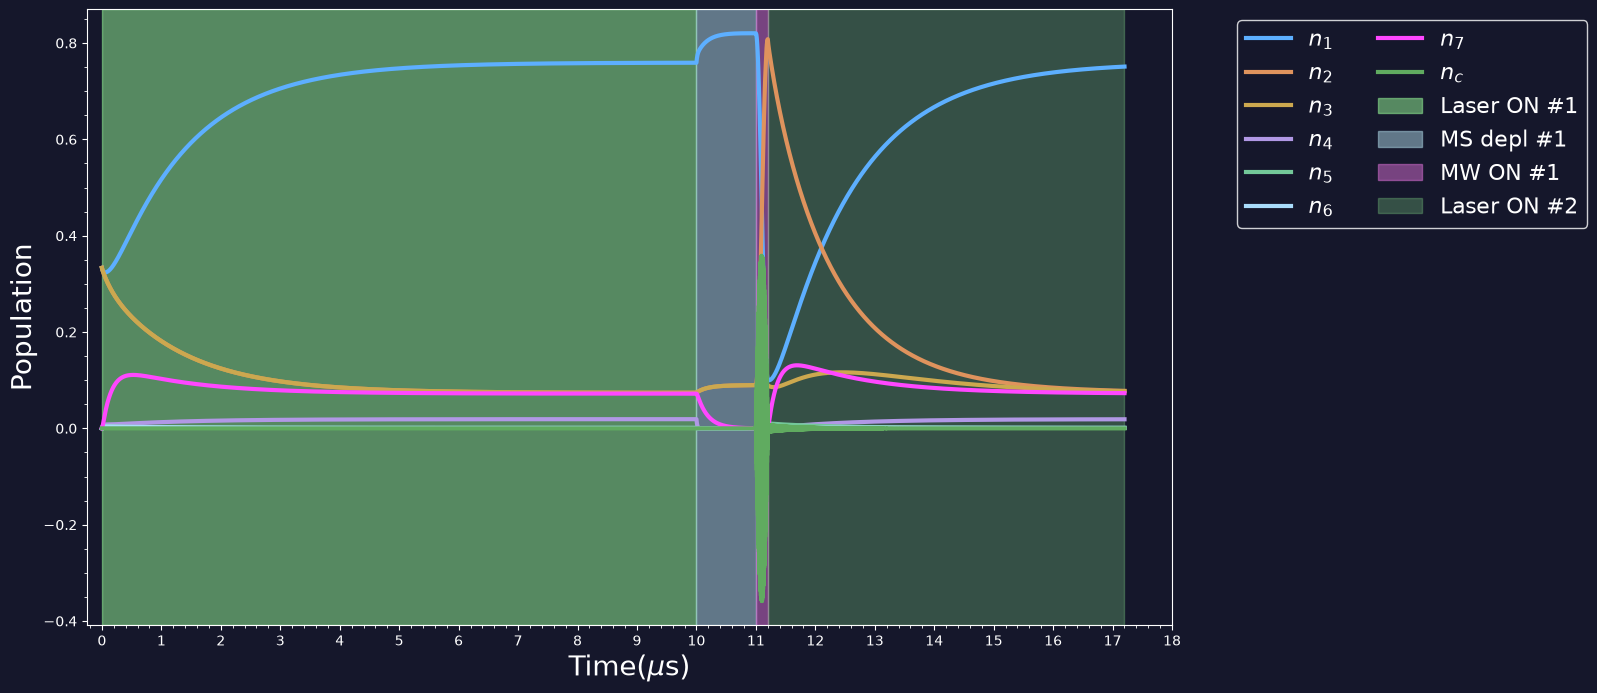

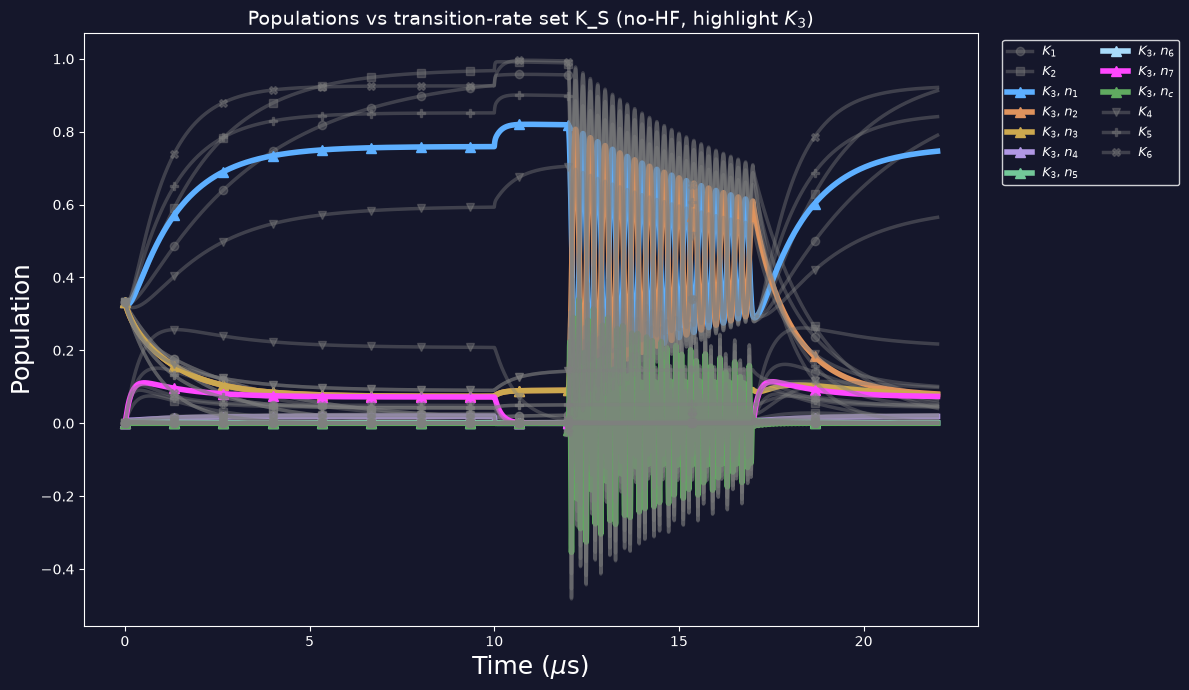

In [6]:
ks = engine.run_or_load(
    "populations_ks_no-HF",
    lambda: engine.compute_populations_ks_comparison("no-HF"),  # all K_S sets, full sequence
    recompute=RECOMPUTE,
)
engine.plot_populations_ks_result(ks, save_as="populations_ks_no-HF.png")
plt.show()

In [7]:
# --- Smoke test: tiny self-contained run to confirm this notebook works ---
try:
    _d = engine.compute_populations(model_label="no-HF", mw_time=5.0,
                                    t_prepare=2.0, t_wait=0.5, t_readout=2.0)
    engine.plot_populations_result(_d, save_as=None)
    _dp = engine.compute_populations(model_label="no-HF", mw_time=None,
                                     t_prepare=2.0, t_wait=0.5, t_readout=2.0)
    engine.plot_populations_result(_dp, save_as=None)
    _dk = engine.compute_populations_ks_comparison("no-HF", k_indices=[0, 2],
                                                   t_prepare=2.0, t_wait=0.5, mw_time=1.0,
                                                   t_readout=2.0)
    engine.plot_populations_ks_result(_dk, save_as=None)
    # HF (14-level Doherty) path — tiny
    _dhf = engine.compute_populations(model_label="Doherty", mw_time=1.0,
                                      t_prepare=2.0, t_wait=0.5, t_readout=2.0)
    engine.plot_populations_result(_dhf, save_as=None)
    engine.plot_populations_comparison_result(_d, _dhf, name_a="7", name_b="14", save_as=None)
    plt.close("all")
    print("SMOKE OK: populations (5 us + pi-pulse + K_S + HF)")
except Exception as _e:
    print("SMOKE FAIL:", repr(_e))

K_S populations [no-HF]:   0%|          | 0/2 [00:00<?, ?it/s]

SMOKE OK: populations (5 us + pi-pulse + K_S + HF)
